# Obtaining data for MA-DPG evaluation form example 02e


In [1]:
# Module imports
import os
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils as utils
from sqlalchemy import create_engine

# assume module imports
import examples as examples
from assume import World
from assume.scenario.loader_csv import load_file, load_scenario_folder

c:\Users\tg3533\AppData\Local\miniconda3\envs\assume-framework\Lib\site-packages\pyomo\common\dependencies.py:471: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  self._loader.exec_module(module)


## 1. Setting scenario parameters

In [2]:
if current_dir := os.path.basename(os.getcwd()) == "MPEC":
    %cd ../../..

example = "small_learning_with_storage"
# actual equilibrium prices
# because one can just see it actually

# all learning units only needed when the demand exceeds 7000 MW and hence only then market power is necessary
equi = [
    36.156,
    36.156,
    36.156,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    85.708,
    85.708,
    85.708,
    85.708,
    85.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
]
# equi = [36.156, 36.156, 36.156] + [55.708] * 20
db_uri = "sqlite:///./examples/local_db/assume_db_8459abd.db"
inputs_dir = "examples/inputs"

scenario = "example_02e"
study_case = "base"

# Set up the database connection
db = create_engine(db_uri)

c:\Users\tg3533\Documents\Code\assume


In [3]:
os.getcwd()

'c:\\Users\\tg3533\\Documents\\Code\\assume'

## 2. Retrieving the data from the best run

### 2.2 Getting the demand dataframe and power plant units

In [4]:
study_case_config = utils.load_config(inputs_dir, scenario, study_case)
start = pd.Timestamp(study_case_config["start_date"])
end = pd.Timestamp(study_case_config["end_date"])

index = pd.date_range(
    start=start,
    end=end,
    freq=study_case_config["time_step"],
)

demand_df = load_file(
    os.path.join(inputs_dir, scenario), study_case_config, "demand_df", index
)
demand_df.head()

INFO:assume.common.utils:Downsampling examples\inputs\example_02e\demand_df.csv successful.


,demand_EOM
2019-01-01 00:00:00,4352.7
2019-01-01 01:00:00,4180.2
2019-01-01 02:00:00,4011.3
2019-01-01 03:00:00,3949.0
2019-01-01 04:00:00,3927.3


In [5]:
pp_units = pd.read_csv(
    os.path.join(inputs_dir, scenario, "powerplant_units.csv"), index_col=0
)
pp_units.reset_index(inplace=True)
pp_units.rename(columns={"name": "unit"}, inplace=True)
pp_units

,unit,technology,bidding_EOM,fuel_type,emission_factor,max_power,min_power,efficiency,additional_cost,unit_operator
0,pp_1,nuclear,powerplant_energy_naive,uranium,0.000,1000,1,0.36,10.0,Operator 1
1,pp_2,nuclear,powerplant_energy_naive,uranium,0.000,1000,1,0.36,12.0,Operator 1
2,pp_3,lignite,powerplant_energy_naive,lignite,0.406,1000,1,0.41,2.0,Operator 1
3,pp_4,hard coal,powerplant_energy_naive,hard coal,0.335,1000,1,0.48,1.0,Operator 1
4,pp_5,hard coal,powerplant_energy_naive,hard coal,0.335,1000,1,0.48,4.0,Operator 1
5,pp_6,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,4.0,Operator 1
6,pp_7,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,10.0,Operator 1
7,pp_8,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,16.0,Operator 1
8,pp_9,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,24.0,Operator 1
9,pp_10,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,30.0,Operator 1


In [6]:
# read storages similar to pp_units
storage_units = pd.read_csv(
    os.path.join(inputs_dir, scenario, "storage_units.csv"), index_col=0
)
storage_units

,technology,bidding_EOM,max_power_charge,max_power_discharge,efficiency_charge,efficiency_discharge,min_soc,max_soc,capacity,initial_soc,additional_cost_charge,additional_cost_discharge,natural_inflow,unit_operator
name,,,,,,,,,,,,,,
Storage 1,PSPP,storage_energy_learning,500,500,0.85,0.95,0.0,1.0,5000,0.0,0.28,0.28,0.0,Operator 1


## NOTE: Delete base dispatch if you retrained

In [7]:
config = utils.load_config(inputs_dir, scenario)
if f"{study_case}_dispatch" in config:
    del config[f"{study_case}_dispatch"]
# Copy the base and new base_dispatch configuration
base_config = config[study_case].copy()
base_dispatch = config[study_case].copy()
base_dispatch["learning_config"] = base_config["learning_config"].copy()

# Modify learning config parameters for base_dispatch
base_dispatch["learning_config"].update(
    {
        "continue_learning": False,
        "trained_policies_save_path": "learned_strategies/base_dispatch/last_policies",
        "trained_policies_load_path": "learned_strategies/base_dispatch/avg_reward_eval_policies",
        "training_episodes": 0,
        "episodes_collecting_initial_experience": 0,
    }
)

base_dispatch.update(
    {
        "learning_mode": False,
    }
)

# Update the config with both sections
config[study_case] = base_config
config[f"{study_case}_dispatch"] = base_dispatch

# Write the updated config back to file
utils.store_config(config, inputs_dir, scenario)

# Define paths
base_dir = Path(
    os.path.join(inputs_dir, scenario, f"learned_strategies/{scenario}_{study_case}")
)
dispatch_dir = Path(
    os.path.join(inputs_dir, scenario, f"learned_strategies/{study_case}_dispatch")
)

# Check if source directory exists
if not base_dir.exists():
    print(f"Source directory {base_dir} does not exist!")
elif dispatch_dir.exists():
    print(f"Target directory {dispatch_dir} already exists!")
else:
    # Create target directory if it doesn't exist
    dispatch_dir.parent.mkdir(parents=True, exist_ok=True)

    # Copy directory
    shutil.copytree(base_dir, dispatch_dir)
    print(f"Successfully copied {base_dir} to {dispatch_dir}")

Target directory examples\inputs\example_02e\learned_strategies\base_dispatch already exists!


In [8]:
world = World(database_uri=db_uri)

load_scenario_folder(world, inputs_dir, scenario, f"{study_case}_dispatch")

INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: examples/inputs/example_02e
INFO:assume.scenario.loader_csv:Study case: base_dispatch
INFO:assume.scenario.loader_csv:Simulation ID: example_02e_base_dispatch
INFO:assume.scenario.loader_csv:examples\inputs\example_02e\unit_operators.csv not found. Returning None
INFO:assume.scenario.loader_csv:examples\inputs\example_02e\exchange_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:examples\inputs\example_02e\industrial_dsm_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:examples\inputs\example_02e\residential_dsm_units.csv not found. Returning None
INFO:assume.common.utils:Downsampling examples\inputs\example_02e\demand_df.csv successful.
INFO:assume.scenario.loader_csv:Adding markets
INFO:assume.scenario.loader_csv:Read units from dataframe
INFO:assume.scenario.loader_csv:Adding power_plant units
INFO:assume.scenario.loader_csv:Adding storage units
INFO:as

### Get mc

Since we want to avoid logging the mc in assume itself, because this is slowing the simualtion down I will get them afterwards. Curretnly the script only runs with time-invariant mc. Hence I test here if that si still the case. 

In [9]:
units = world.unit_operators["Operator 1"].units
for name, unit in units.items():
    if (
        hasattr(unit, "marginal_cost")
        and unit.marginal_cost is not None
        and np.all(np.array(unit.marginal_cost) != 0)
    ):
        mc = np.array(unit.marginal_cost)
        # Check all values are the same
        assert np.all(mc == mc[0]), f"Marginal costs for {name} are not constant: {mc}"
        # Check none are zero
        assert np.all(mc != 0), f"Marginal costs for {name} contain zero: {mc}"
        print(f"{name}: marginal_cost = {mc[0]}")
    else:
        # For storages or units without marginal_cost, use average of additional_cost_charge and additional_cost_discharge
        charge = getattr(unit, "additional_cost_charge", None)
        discharge = getattr(unit, "additional_cost_discharge", None)
        if charge is not None and discharge is not None:
            avg_cost = (charge + discharge) / 2
            print(f"{name}: average storage cost = {avg_cost}")
        else:
            print(f"{name}: No marginal or storage cost found!")

pp_1: marginal_cost = 12.5
pp_2: marginal_cost = 14.5
pp_3: marginal_cost = 31.146341463414636
pp_4: marginal_cost = 36.15625
pp_5: marginal_cost = 39.15625
pp_6: marginal_cost = 55.708333333333336
pp_7: marginal_cost = 61.708333333333336
pp_8: marginal_cost = 67.70833333333334
pp_9: marginal_cost = 75.70833333333334
pp_10: marginal_cost = 81.70833333333334
pp_11: marginal_cost = 87.70833333333334
pp_12: marginal_cost = 91.70833333333334
Storage 1: average storage cost = 0.28


In [10]:
# Suppose unit.marginal_cost is a list/array of values for each unit
# Collect all marginal_cost series in a dict
costs_dict = {
    name: (
        unit.marginal_cost
        if hasattr(unit, "marginal_cost")
        and unit.marginal_cost is not None
        and np.all(np.array(unit.marginal_cost) != 0)
        else (
            (
                getattr(unit, "additional_cost_charge", None)
                + getattr(unit, "additional_cost_discharge", None)
            )
            / 2
            if getattr(unit, "additional_cost_charge", None) is not None
            and getattr(unit, "additional_cost_discharge", None) is not None
            else None
        )
    )
    for name, unit in world.unit_operators["Operator 1"].units.items()
}

# Find the length of the series (assuming all are the same length)
n = len(next(iter(costs_dict.values())))

# Optionally, create a time index (e.g., hourly from start_date)
start = pd.Timestamp(study_case_config["start_date"])
time_index = pd.date_range(start=start, periods=n, freq="h")  # adjust freq as needed

# Create the DataFrame
marginal_costs_df = pd.DataFrame(costs_dict, index=time_index)
marginal_costs_df

,pp_1,pp_2,pp_3,pp_4,pp_5,pp_6,pp_7,pp_8,pp_9,pp_10,pp_11,pp_12,Storage 1
2019-01-01 00:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333,0.28
2019-01-01 01:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333,0.28
2019-01-01 02:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333,0.28
2019-01-01 03:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333,0.28
2019-01-01 04:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333,0.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-08 20:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333,0.28
2019-01-08 21:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333,0.28
2019-01-08 22:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333,0.28
2019-01-08 23:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333,0.28


In [11]:
query = f"SELECT * FROM market_orders where simulation = '{scenario}_{study_case}'"
market_orders_df = pd.read_sql(query, db)
market_orders_df

,start_time,accepted_price,accepted_volume,bid_id,bid_type,end_time,market_id,node,price,simulation,unit_id,volume
0,2019-01-01 01:00:00.000000,39.156250,-500.0,Storage 1_1,None,2019-01-01 02:00:00.000000,EOM,node0,99.997292,example_02e_base,Storage 1,-500.0
1,2019-01-01 01:00:00.000000,39.156250,1000.0,pp_1_1,None,2019-01-01 02:00:00.000000,EOM,node0,12.500000,example_02e_base,pp_1,1000.0
2,2019-01-01 01:00:00.000000,39.156250,1000.0,pp_2_1,None,2019-01-01 02:00:00.000000,EOM,node0,14.500000,example_02e_base,pp_2,1000.0
3,2019-01-01 01:00:00.000000,39.156250,1000.0,pp_3_1,None,2019-01-01 02:00:00.000000,EOM,node0,31.146341,example_02e_base,pp_3,1000.0
4,2019-01-01 01:00:00.000000,39.156250,1000.0,pp_4_1,None,2019-01-01 02:00:00.000000,EOM,node0,36.156250,example_02e_base,pp_4,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2669,2019-01-08 23:00:00.000000,61.708333,0.0,pp_9_1,None,2019-01-09 00:00:00.000000,EOM,node0,75.708333,example_02e_base,pp_9,500.0
2670,2019-01-08 23:00:00.000000,61.708333,0.0,pp_10_1,None,2019-01-09 00:00:00.000000,EOM,node0,81.708333,example_02e_base,pp_10,500.0
2671,2019-01-08 23:00:00.000000,61.708333,0.0,pp_11_1,None,2019-01-09 00:00:00.000000,EOM,node0,87.708333,example_02e_base,pp_11,500.0
2672,2019-01-08 23:00:00.000000,61.708333,0.0,pp_12_1,None,2019-01-09 00:00:00.000000,EOM,node0,91.708333,example_02e_base,pp_12,500.0


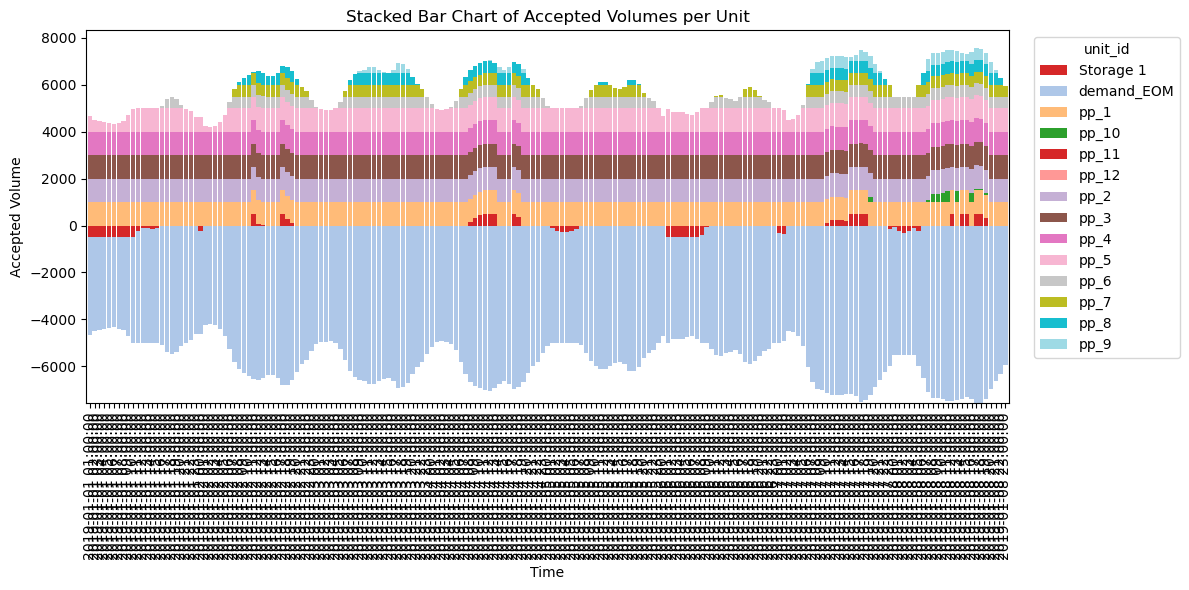

In [12]:
# ...existing code...
market_orders_df["time"] = pd.to_datetime(market_orders_df["start_time"])

plot_df = (
    market_orders_df.groupby(["time", "unit_id"], as_index=False)["accepted_volume"]
    .sum()
    .pivot(index="time", columns="unit_id", values="accepted_volume")
    .fillna(0)
    .sort_index()
)

# make sure labels are strings (optional but helps robust matching)
plot_df.columns = plot_df.columns.astype(str)

# base colors for all units
base_colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(plot_df.columns)))
color_map = {col: base_colors[i] for i, col in enumerate(plot_df.columns)}

# override one specific unit color
color_map["Storage 1"] = "#d62728"  # red, choose any hex you want

# colors must follow column order
colors = [color_map[col] for col in plot_df.columns]

ax = plot_df.plot(kind="bar", stacked=True, figsize=(12, 6), width=0.9, color=colors)
ax.set_xlabel("Time")
ax.set_ylabel("Accepted Volume")
ax.set_title("Stacked Bar Chart of Accepted Volumes per Unit")
ax.legend(title="unit_id", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3. Establish Sampling of days to be analysed

Here we sample from the entire training data a subset of days, for which we test if the profit of all drl agents is similar to their MPEC formulation. 

In [13]:
sampled_indices = utils.sample_seasonal_weeks(demand_df.index)
# TODO: LÖSCHEN NUR FÜR FASTER SOLAVBIILTY AS 1 Week runs into run time limit
# sampled_indices = sampled_indices[:1]

sampled_indices = [demand_df.index.date[25]]
sampled_indices

Spring complete weeks: []
Summer complete weeks: []
Fall complete weeks: []
Winter complete weeks: []


[datetime.date(2019, 1, 2)]

## 3.1 Get sample subset

In [14]:
demand_df["date"] = demand_df.index.date
sample_demand_df = demand_df.loc[demand_df["date"].isin(sampled_indices)]
rest_demand_df = demand_df.loc[~demand_df["date"].isin(sampled_indices)]
sample_demand_df.head()

,demand_EOM,date
2019-01-02 00:00:00,4406.4,2019-01-02
2019-01-02 01:00:00,4238.2,2019-01-02
2019-01-02 02:00:00,4187.0,2019-01-02
2019-01-02 03:00:00,4237.8,2019-01-02
2019-01-02 04:00:00,4408.8,2019-01-02


In [15]:
query = f"SELECT * FROM unit_dispatch where simulation = '{scenario}_{study_case}'"
dispatch_df = pd.read_sql(query, db)
# dispatch_df = dispatch_df.drop_duplicates(subset=["time", "unit"], keep="first")

dispatch_df = dispatch_df.sort_values("time")


dispatch_df.index = pd.to_datetime(dispatch_df["time"])
dispatch_df.drop(columns=["time"], inplace=True)
dispatch_df["date"] = dispatch_df.index.date

# merge marginal_costs based on unit and time
# Reset index to get time as a column
mc_long = marginal_costs_df.reset_index().melt(
    id_vars="index", var_name="unit", value_name="marginal_cost"
)
mc_long = mc_long.rename(columns={"index": "time"})  # Rename index to time if needed

# Now merge with dispatch_df on 'time' and 'unit'
dispatch_df = dispatch_df.merge(mc_long, on=["time", "unit"], how="left")

sample_dispatch_df = dispatch_df.loc[dispatch_df["date"].isin(sampled_indices)]
rest_dispatch_df = dispatch_df.loc[~dispatch_df["date"].isin(sampled_indices)]
sample_dispatch_df

,time,energy_cashflow,energy_generation_costs,heat,power,simulation,soc,total_costs,unit,date,marginal_cost
336,2019-01-02 00:00:00,-172538.100000,1.321920e+07,NaN,-4406.400000,example_02e_base,NaN,NaN,demand_EOM,2019-01-02,NaN
337,2019-01-02 00:00:00,-9258.610478,6.620682e+01,NaN,-236.452941,example_02e_base,0.959803,66.206824,Storage 1,2019-01-02,0.280000
338,2019-01-02 00:00:00,0.000000,0.000000e+00,0.0,0.000000,example_02e_base,NaN,NaN,pp_12,2019-01-02,91.708333
339,2019-01-02 00:00:00,0.000000,0.000000e+00,0.0,0.000000,example_02e_base,NaN,NaN,pp_11,2019-01-02,87.708333
340,2019-01-02 00:00:00,0.000000,0.000000e+00,0.0,0.000000,example_02e_base,NaN,NaN,pp_9,2019-01-02,75.708333
...,...,...,...,...,...,...,...,...,...,...,...
667,2019-01-02 23:00:00,55708.333333,1.450000e+04,0.0,1000.000000,example_02e_base,NaN,NaN,pp_2,2019-01-02,14.500000
668,2019-01-02 23:00:00,55708.333333,3.114634e+04,0.0,1000.000000,example_02e_base,NaN,NaN,pp_3,2019-01-02,31.146341
669,2019-01-02 23:00:00,0.000000,0.000000e+00,0.0,0.000000,example_02e_base,NaN,NaN,pp_7,2019-01-02,61.708333
670,2019-01-02 23:00:00,55708.333333,3.915625e+04,0.0,1000.000000,example_02e_base,NaN,NaN,pp_5,2019-01-02,39.156250


In [16]:
# sample market orders as well
market_orders_df.index = pd.to_datetime(market_orders_df["start_time"])
market_orders_df = market_orders_df.drop(columns=["start_time"])
market_orders_df["date"] = market_orders_df.index.date

sample_market_orders_df = market_orders_df.loc[
    market_orders_df["date"].isin(sampled_indices)
]
rest_market_orders_df = market_orders_df.loc[
    ~market_orders_df["date"].isin(sampled_indices)
]
sample_market_orders_df.head()

,accepted_price,accepted_volume,bid_id,bid_type,end_time,market_id,node,price,simulation,unit_id,volume,time,date
start_time,,,,,,,,,,,,,
2019-01-02,39.15625,-236.452941,Storage 1_1,None,2019-01-02 01:00:00.000000,EOM,node0,46.869400,example_02e_base,Storage 1,-236.452941,2019-01-02,2019-01-02
2019-01-02,39.15625,1000.000000,pp_1_1,None,2019-01-02 01:00:00.000000,EOM,node0,12.500000,example_02e_base,pp_1,1000.000000,2019-01-02,2019-01-02
2019-01-02,39.15625,1000.000000,pp_2_1,None,2019-01-02 01:00:00.000000,EOM,node0,14.500000,example_02e_base,pp_2,1000.000000,2019-01-02,2019-01-02
2019-01-02,39.15625,1000.000000,pp_3_1,None,2019-01-02 01:00:00.000000,EOM,node0,31.146341,example_02e_base,pp_3,1000.000000,2019-01-02,2019-01-02
2019-01-02,39.15625,1000.000000,pp_4_1,None,2019-01-02 01:00:00.000000,EOM,node0,36.156250,example_02e_base,pp_4,1000.000000,2019-01-02,2019-01-02


## 2.3 Bi-Level Optimisation 

### Defintion for case

In [17]:
big_w = 100000  # weight for duality gap objective
k_max = 2  # maximum multiplier for strategic bidding

### Input data transformation for Optimisation Problem 

In [18]:
# gens
gens_df = utils.create_gens_df(pp_units, dispatch_df)
gens_df.head(15)

,index,unit,technology,bidding_EOM,fuel_type,emission_factor,g_max,u_0,efficiency,additional_cost,unit_operator,r_up,r_down,k_up,k_down,g_0,mc
0,0,pp_1,nuclear,powerplant_energy_naive,uranium,0.000,1000,1,0.36,10.0,Operator 1,1000,1000,0,0,0,12.500000
1,1,pp_2,nuclear,powerplant_energy_naive,uranium,0.000,1000,1,0.36,12.0,Operator 1,1000,1000,0,0,0,14.500000
2,2,pp_3,lignite,powerplant_energy_naive,lignite,0.406,1000,1,0.41,2.0,Operator 1,1000,1000,0,0,0,31.146341
3,3,pp_4,hard coal,powerplant_energy_naive,hard coal,0.335,1000,1,0.48,1.0,Operator 1,1000,1000,0,0,0,36.156250
4,4,pp_5,hard coal,powerplant_energy_naive,hard coal,0.335,1000,1,0.48,4.0,Operator 1,1000,1000,0,0,0,39.156250
5,5,pp_6,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,4.0,Operator 1,500,500,0,0,0,55.708333
6,6,pp_7,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,10.0,Operator 1,500,500,0,0,0,61.708333
7,7,pp_8,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,16.0,Operator 1,500,500,0,0,0,67.708333
8,8,pp_9,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,24.0,Operator 1,500,500,0,0,0,75.708333
9,9,pp_10,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,30.0,Operator 1,500,500,0,0,0,81.708333


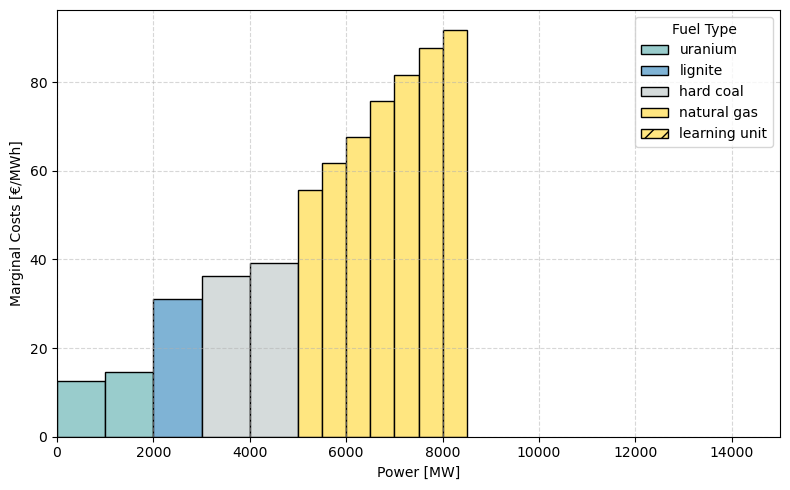

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Sortiere nach marginalen Kosten (mc)
gens_sorted = gens_df.sort_values("mc").reset_index(drop=True)

# Farben und Muster für die Balken
color_map = {
    "uranium": "#99cccc",
    "lignite": "#7fb3d5",
    "hard coal": "#d5dbdb",
    "natural gas": "#ffe680",
    "learning unit": "#ffe680",  # gleiche Farbe wie gas, aber mit Muster
}
hatch_map = {
    "learning unit": "//",
}

# Linke Kante für jeden Balken
left_edges = np.concatenate([[0], gens_sorted["g_max"].cumsum()[:-1]])

plt.figure(figsize=(8, 5))

bars = []
labels = []
for i, row in gens_sorted.iterrows():
    # Fuel-Type bestimmen
    if "bidding_EOM" in row and row["bidding_EOM"] == "pp_learning_single_bid":
        fuel = "learning unit"
    else:
        fuel = row["fuel_type"]
    color = color_map.get(fuel, "#cccccc")
    hatch = hatch_map.get(fuel, None)
    bar = plt.bar(
        left_edges[i],
        row["mc"],
        width=row["g_max"],
        align="edge",
        color=color,
        edgecolor="black",
        hatch=hatch,
        label=fuel if fuel not in labels else "",
    )
    bars.append(bar)
    labels.append(fuel)

# Legende manuell erstellen, damit jede Kategorie nur einmal erscheint
handles = []
legend_labels = []
for fuel, color in color_map.items():
    hatch = hatch_map.get(fuel, None)
    handle = plt.Rectangle(
        (0, 0), 1, 1, facecolor=color, edgecolor="black", hatch=hatch
    )
    handles.append(handle)
    legend_labels.append(fuel)

plt.legend(handles, legend_labels, title="Fuel Type", loc="upper right")
plt.xlabel("Power [MW]")
plt.ylabel("Marginal Costs [€/MWh]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(0, 15000)
plt.tight_layout()
plt.show()

### Translate actions of RL model into k_values

In [20]:
# Merge on both 'unit_id' and 'time' columns
merged_df = sample_market_orders_df.merge(
    sample_dispatch_df[["unit", "time", "marginal_cost"]].reset_index(),
    left_on=["unit_id", "start_time"],
    right_on=["unit", "time"],
    how="left",
)
merged_df.head()

,accepted_price,accepted_volume,bid_id,bid_type,end_time,market_id,node,price,simulation,unit_id,volume,time_x,date,index,unit,time_y,marginal_cost
0,39.15625,-236.452941,Storage 1_1,None,2019-01-02 01:00:00.000000,EOM,node0,46.869400,example_02e_base,Storage 1,-236.452941,2019-01-02,2019-01-02,337,Storage 1,2019-01-02,0.280000
1,39.15625,1000.000000,pp_1_1,None,2019-01-02 01:00:00.000000,EOM,node0,12.500000,example_02e_base,pp_1,1000.000000,2019-01-02,2019-01-02,348,pp_1,2019-01-02,12.500000
2,39.15625,1000.000000,pp_2_1,None,2019-01-02 01:00:00.000000,EOM,node0,14.500000,example_02e_base,pp_2,1000.000000,2019-01-02,2019-01-02,347,pp_2,2019-01-02,14.500000
3,39.15625,1000.000000,pp_3_1,None,2019-01-02 01:00:00.000000,EOM,node0,31.146341,example_02e_base,pp_3,1000.000000,2019-01-02,2019-01-02,346,pp_3,2019-01-02,31.146341
4,39.15625,1000.000000,pp_4_1,None,2019-01-02 01:00:00.000000,EOM,node0,36.156250,example_02e_base,pp_4,1000.000000,2019-01-02,2019-01-02,345,pp_4,2019-01-02,36.156250


storages do not have a mc value yet we need to get them from the storage_units_df depending on the direction of the valume we use the additional_costs_charge or discharge

In [21]:
# Identify storage units (those with soc column populated)
storage_units_in_dispatch = dispatch_df[dispatch_df["soc"].notna()]["unit"].unique()
storage_dispatch = dispatch_df[dispatch_df["unit"].isin(storage_units_in_dispatch)]

# Pivot: one column per storage, rows = time, values = power
storage_pivot = storage_dispatch.pivot_table(
    index="time", columns="unit", values="power", aggfunc="first"
).fillna(0.0)

# Net storage dispatch: sum across all storages per hour
# positive = net discharge (generation), negative = net charge (demand)
net_storage = storage_pivot.sum(axis=1)

print("=== Fixed storage dispatch ===")
print(f"Storage units: {len(storage_units_in_dispatch)}")
print(f"Time range: {net_storage.index.min()} to {net_storage.index.max()}")
n_charge = (net_storage < 0).sum()
n_discharge = (net_storage > 0).sum()
n_idle = (net_storage == 0).sum()
print(f"Hours charging: {n_charge}, discharging: {n_discharge}, idle: {n_idle}")
print(
    f"Max charge: {net_storage.min():.0f} MW, max discharge: {net_storage.max():.0f} MW"
)

=== Fixed storage dispatch ===
Storage units: 1
Time range: 2019-01-01 00:00:00 to 2019-01-08 23:00:00
Hours charging: 40, discharging: 30, idle: 122
Max charge: -500 MW, max discharge: 500 MW


In [22]:
k_df = merged_df[["unit_id", "time_y", "price", "marginal_cost"]].copy()
k_df = k_df.rename(columns={"time_y": "time"})
k_df

,unit_id,time,price,marginal_cost
0,Storage 1,2019-01-02 00:00:00,46.869400,0.280000
1,pp_1,2019-01-02 00:00:00,12.500000,12.500000
2,pp_2,2019-01-02 00:00:00,14.500000,14.500000
3,pp_3,2019-01-02 00:00:00,31.146341,31.146341
4,pp_4,2019-01-02 00:00:00,36.156250,36.156250
...,...,...,...,...
331,pp_9,2019-01-02 23:00:00,75.708333,75.708333
332,pp_10,2019-01-02 23:00:00,81.708333,81.708333
333,pp_11,2019-01-02 23:00:00,87.708333,87.708333
334,pp_12,2019-01-02 23:00:00,91.708333,91.708333


In [23]:
k_df.head(14)

,unit_id,time,price,marginal_cost
0,Storage 1,2019-01-02,46.869400,0.280000
1,pp_1,2019-01-02,12.500000,12.500000
2,pp_2,2019-01-02,14.500000,14.500000
3,pp_3,2019-01-02,31.146341,31.146341
4,pp_4,2019-01-02,36.156250,36.156250
5,pp_5,2019-01-02,39.156250,39.156250
6,demand_EOM,2019-01-02,3000.000000,NaN
7,pp_6,2019-01-02,55.708333,55.708333
8,pp_7,2019-01-02,61.708333,61.708333
9,pp_8,2019-01-02,67.708333,67.708333


In [24]:
def obtain_k_values(k_df):
    # transformed actions into k_values, one per generator
    k_df["k"] = k_df["price"] / k_df["marginal_cost"]

    # replace inf with 0
    k_df["k"] = k_df["k"].replace(np.inf, 0)

    # delete rows where unit_id is none
    k_df = k_df[k_df["unit_id"].notna()]

    k_values_df = k_df.pivot(index="time", columns="unit_id", values="k")
    # k_values_df.reset_index(inplace=True)

    # sort columns to match the order of the columns in the gens_df
    k_values_df["date"] = k_values_df.index.date
    return k_values_df

In [25]:
k_values_df = obtain_k_values(k_df)
k_values_df.head()

unit_id,Storage 1,demand_EOM,pp_1,pp_10,pp_11,pp_12,pp_2,pp_3,pp_4,pp_5,pp_6,pp_7,pp_8,pp_9,date
time,,,,,,,,,,,,,,,
2019-01-02 00:00:00,167.390714,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-01-02
2019-01-02 01:00:00,168.743651,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-01-02
2019-01-02 02:00:00,245.861326,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-01-02
2019-01-02 03:00:00,355.369922,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-01-02
2019-01-02 04:00:00,356.009865,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-01-02


In [26]:
# read availability df in same directory as powerplants and storages, if the file does not exist we initalize an empty df
try:
    availabilities = pd.read_csv(
        os.path.join(inputs_dir, scenario, "availability_df.csv"), index_col=0
    )
except FileNotFoundError:
    availabilities = pd.DataFrame()


availability_df = k_values_df.copy()
# drop column date
availability_df = availability_df.drop(columns=["date"])
# if columns in availabilities is also in k_values_df then we can use it directly otherwise we assume an availability of 1.0
# itterate over availability_df columns and check if present in availabilities columns
for col in availability_df.columns:
    if col in availabilities.columns:
        # use values in availabilities df where the index matches
        availability_df[col] = (
            availabilities[col].reindex(availability_df.index).fillna(1.0)
        )
    else:
        availability_df[col] = 1.0


availability_df.head()

unit_id,Storage 1,demand_EOM,pp_1,pp_10,pp_11,pp_12,pp_2,pp_3,pp_4,pp_5,pp_6,pp_7,pp_8,pp_9
time,,,,,,,,,,,,,,
2019-01-02 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2019-01-02 01:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2019-01-02 02:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2019-01-02 03:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2019-01-02 04:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Join demand and price bid

Since assume has the problem that the market always starts at 1 instead of zero we need to equal the modelling times here to avoid problems. 

In [27]:
# drop demand_df rows where start_time is not in sample_market_orders time column
sample_demand_df = sample_demand_df[
    sample_demand_df.index.isin(sample_market_orders_df.index)
]

demand_df = utils.join_demand_market_orders(sample_demand_df, sample_market_orders_df)
demand_df

,volume_1,price_1,date
datetime,,,
2019-01-02 00:00:00,4406.4,3000.0,2019-01-02
2019-01-02 01:00:00,4238.2,3000.0,2019-01-02
2019-01-02 02:00:00,4187.0,3000.0,2019-01-02
2019-01-02 03:00:00,4237.8,3000.0,2019-01-02
2019-01-02 04:00:00,4408.8,3000.0,2019-01-02
2019-01-02 05:00:00,4709.7,3000.0,2019-01-02
2019-01-02 06:00:00,5273.2,3000.0,2019-01-02
2019-01-02 07:00:00,5812.7,3000.0,2019-01-02
2019-01-02 08:00:00,6132.2,3000.0,2019-01-02


## Run MPEC

In [ ]:
import os
import sys
import time

# Add MPEC folder to path so we can import the modules
mpec_dir = os.path.join(os.getcwd(), "examples", "notebooks", "MPEC")
if mpec_dir not in sys.path:
    sys.path.insert(0, mpec_dir)

from bilevel_opt import find_optimal_dispatch_quadratic_fixed_storage
from uc_problem import solve_uc_problem

res_lambda = {}
res_lambda_hat = {}
res_uc_mcp = {}

start = pd.to_datetime("2019-01-02 01:00")
end = pd.to_datetime("2019-01-02 23:00")
index = pd.date_range(start, end, freq="h")

opt_gen = "pp_6"
k_max = 300

demand_df_short = demand_df.copy().loc[index]
demand_df_short.drop(columns=["date"], inplace=True)

k_times = k_values_df.copy().loc[index].index
net_storage_aligned = net_storage.reindex(k_times).fillna(0.0)
net_storage_aligned.index = range(len(k_times))

gens_df_idx = gens_df.set_index("unit") if "unit" in gens_df.columns else gens_df.copy()
gen_names = list(gens_df_idx.index)

# Use the short (23h) dataframes consistently
demand_df_r = demand_df_short.reset_index(drop=True).copy()
k_values_r = k_values_df.loc[index].reset_index(drop=True).copy()
avail_r = availability_df.loc[index].reset_index(drop=True).copy()

# Filter k_values and availability to only generator columns
k_values_r = k_values_r[[c for c in k_values_r.columns if c in gen_names]]
avail_r = avail_r[[c for c in avail_r.columns if c in gen_names]]

# Fold storage dispatch into demand (at 3000 €/MWh price)
# net_storage > 0 = discharge (reduces demand), < 0 = charge (increases demand)
demand_df_r["volume_1"] = demand_df_r["volume_1"] - net_storage_aligned.values
demand_df_r["volume_1"] = demand_df_r["volume_1"].clip(lower=0.01)
print(
    f"Adjusted demand by storage: min={net_storage_aligned.min():.0f}, max={net_storage_aligned.max():.0f} MW"
)
print(
    f"Adjusted demand range: {demand_df_r['volume_1'].min():.0f} to {demand_df_r['volume_1'].max():.0f} MW"
)

mc_df = pd.DataFrame(
    {gen: gens_df_idx.at[gen, "mc"] for gen in gen_names}, index=demand_df_r.index
)

t0 = time.time()
main_df, supp_df, k_vals = find_optimal_dispatch_quadratic_fixed_storage(
    gens_df=gens_df_idx,
    k_values_df=k_values_r,
    availabilities_df=avail_r,
    demand_df=demand_df_r,
    k_max=k_max,
    opt_gen=opt_gen,
    fixed_storage_dispatch=None,
    big_w=10000,
    time_limit=12000,
    big_M=10e6,
    demand_bids=1,
    mc_df=mc_df,
)
t_mpec = time.time() - t0

if main_df is None:
    print(f"  MPEC INFEASIBLE ({t_mpec:.1f}s)")
else:
    res_lambda[opt_gen] = main_df["mcp"].astype(float)
    res_lambda_hat[opt_gen] = main_df["mcp_hat"].astype(float)

    # UC re-solve: update k_values with MPEC result, then solve UC
    k_values_uc = k_values_r.copy()
    k_series = pd.to_numeric(k_vals["k"], errors="coerce")
    fallback = pd.to_numeric(k_values_uc[opt_gen], errors="coerce").fillna(1.0)
    k_values_uc[opt_gen] = k_series.fillna(fallback).astype(float).values
    for col in k_values_uc.columns:
        k_values_uc[col] = pd.to_numeric(k_values_uc[col], errors="coerce").fillna(1.0)

    t0 = time.time()
    uc_main, uc_supp = solve_uc_problem(
        gens_df=gens_df_idx,
        demand_df=demand_df_r,
        k_values_df=k_values_uc,
        availabilities_df=avail_r,
        demand_bids=1,
        mc_df=mc_df,
        fixed_storage_dispatch=None,
    )
    t_uc = time.time() - t0

    res_uc_mcp[opt_gen] = uc_main["mcp"].astype(float)
    print(f"  OK (MPEC {t_mpec:.1f}s, UC {t_uc:.1f}s)")
    print(
        f"    lambda_: {res_lambda[opt_gen].min():.1f} to {res_lambda[opt_gen].max():.1f}"
    )
    print(
        f"    lambda_hat: {res_lambda_hat[opt_gen].min():.1f} to {res_lambda_hat[opt_gen].max():.1f}"
    )
    print(
        f"    UC MCP: {res_uc_mcp[opt_gen].min():.1f} to {res_uc_mcp[opt_gen].max():.1f}"
    )

In [ ]:
res_uc_mcp_nostart = {}

k_values_uc = k_values_r.copy()

t0 = time.time()
uc_main, uc_supp = solve_uc_problem(
    gens_df=gens_df_idx,
    demand_df=demand_df_r,
    k_values_df=k_values_uc,
    availabilities_df=avail_r,
    demand_bids=1,
    mc_df=mc_df,
    fixed_storage_dispatch=None,
)
t_uc = time.time() - t0

res_uc_mcp_nostart[opt_gen] = uc_main["mcp"].astype(float)
print(
    f"    UC MCP: {res_uc_mcp_nostart[opt_gen].min():.1f} to {res_uc_mcp_nostart[opt_gen].max():.1f}"
)

In [ ]:
demand_df_r

In [ ]:
# plot results market prices

plt.plot(res_uc_mcp[opt_gen], label="UC MCP")
plt.plot(res_lambda[opt_gen], label="MPEC Lambda")
plt.plot(res_uc_mcp_nostart[opt_gen], label="UC MCP No MPEC Start")
# plt.plot(res_lambda_hat[opt_gen], label="MPEC Lambda Hat")
plt.xlabel("Time")
plt.ylabel("Market Price")
plt.title("Comparison of Market Prices")
plt.legend()
plt.show()

In [ ]:
# plot demand_df_r with horizontal lines in 5000 steps for y axis

plt.plot(demand_df_r["volume_1"], label="Demand (adjusted for storage)")
plt.xlabel("Time")
plt.ylabel("Demand [MW]")
plt.title("Adjusted Demand over Time")

# show grid
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import os
import sys
import time

# Add MPEC folder to path so we can import the modules
mpec_dir = os.path.join(os.getcwd(), "examples", "notebooks", "MPEC")
if mpec_dir not in sys.path:
    sys.path.insert(0, mpec_dir)

from bilevel_opt import find_optimal_dispatch_quadratic_fixed_storage
from uc_problem import solve_uc_problem

res_lambda = {}
res_lambda_hat = {}
res_uc_mcp = {}

start = pd.to_datetime("2019-01-02 01:00")
end = pd.to_datetime("2019-01-02 23:00")
index = pd.date_range(start, end, freq="h")

opt_gen = "pp_6"
k_max = 300

demand_df_short = demand_df.copy().loc[index]
demand_df_short.drop(columns=["date"], inplace=True)

k_times = k_values_df.copy().loc[index].index
net_storage_aligned = net_storage.reindex(k_times).fillna(0.0)
net_storage_aligned.index = range(len(k_times))

gens_df_idx = gens_df.set_index("unit") if "unit" in gens_df.columns else gens_df.copy()
gen_names = list(gens_df_idx.index)

# Use the short (23h) dataframes consistently
demand_df_r = demand_df_short.reset_index(drop=True).copy()
k_values_r = k_values_df.loc[index].reset_index(drop=True).copy()
avail_r = availability_df.loc[index].reset_index(drop=True).copy()

# Filter k_values and availability to only generator columns
k_values_r = k_values_r[[c for c in k_values_r.columns if c in gen_names]]
avail_r = avail_r[[c for c in avail_r.columns if c in gen_names]]

mc_df = pd.DataFrame(
    {gen: gens_df_idx.at[gen, "mc"] for gen in gen_names}, index=demand_df_r.index
)
fixed_sd = net_storage_aligned.copy()
fixed_sd.index = demand_df_r.index

t0 = time.time()
main_df, supp_df, k_vals = find_optimal_dispatch_quadratic_fixed_storage(
    gens_df=gens_df_idx,
    k_values_df=k_values_r,
    availabilities_df=avail_r,
    demand_df=demand_df_r,
    k_max=k_max,
    opt_gen=opt_gen,
    fixed_storage_dispatch=None,
    big_w=10000,
    time_limit=12000,
    big_M=10e6,
    demand_bids=1,
    mc_df=mc_df,
)
t_mpec = time.time() - t0

if main_df is None:
    print(f"  MPEC INFEASIBLE ({t_mpec:.1f}s)")
else:
    res_lambda[opt_gen] = main_df["mcp"].astype(float)
    res_lambda_hat[opt_gen] = main_df["mcp_hat"].astype(float)

    # UC re-solve: update k_values with MPEC result, then solve UC
    k_values_uc = k_values_r.copy()
    k_series = pd.to_numeric(k_vals["k"], errors="coerce")
    fallback = pd.to_numeric(k_values_uc[opt_gen], errors="coerce").fillna(1.0)
    k_values_uc[opt_gen] = k_series.fillna(fallback).astype(float).values
    for col in k_values_uc.columns:
        k_values_uc[col] = pd.to_numeric(k_values_uc[col], errors="coerce").fillna(1.0)

    t0 = time.time()
    uc_main, uc_supp = solve_uc_problem(
        gens_df=gens_df_idx,
        demand_df=demand_df_r,
        k_values_df=k_values_uc,
        availabilities_df=avail_r,
        demand_bids=1,
        mc_df=mc_df,
        fixed_storage_dispatch=None,
    )
    t_uc = time.time() - t0

    res_uc_mcp[opt_gen] = uc_main["mcp"].astype(float)
    print(f"  OK (MPEC {t_mpec:.1f}s, UC {t_uc:.1f}s)")
    print(
        f"    lambda_: {res_lambda[opt_gen].min():.1f} to {res_lambda[opt_gen].max():.1f}"
    )
    print(
        f"    lambda_hat: {res_lambda_hat[opt_gen].min():.1f} to {res_lambda_hat[opt_gen].max():.1f}"
    )
    print(
        f"    UC MCP: {res_uc_mcp[opt_gen].min():.1f} to {res_uc_mcp[opt_gen].max():.1f}"
    )